In [13]:
import torch
import torch.nn as nn

In [14]:
device = 'cpu'
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator()
print(device)


mps


In [55]:
class ColorizationNetwork(nn.Module):
    def __init__(self,n_classes):
        super().__init__()
        self.encoder = nn.Sequential(

            nn.Conv2d(1,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32,128,3,stride=2,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128,256,3,stride=2,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(
                256,
                128,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(
                128,
                64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            nn.Conv2d(64,n_classes,1)
        )
    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)

        return x


In [56]:
model = ColorizationNetwork(n_classes=32).to(device)

In [57]:
criterion = nn.CrossEntropyLoss()

In [58]:
optimizer = torch.optim.Adam(model.parameters(),lr=0.01)

In [59]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset

class ColorizationDataset(Dataset):

    def __init__(self, x_dir, y_dir,file_path):
        self.x_dir = x_dir
        self.y_dir = y_dir
        self.files = []
        with open(file_path, 'r') as f:
            self.files = [line.strip() for line in f]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        file_name = self.files[idx]

        x = np.load(os.path.join(self.x_dir, file_name))
        y = np.load(os.path.join(self.y_dir, file_name))

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.long)

        # dodaj channel dimension
        x = x.unsqueeze(0)

        return x, y

In [60]:
from torch.utils.data import DataLoader
dir_x = "/Users/jacek/Desktop/GitHubProjects/pictures-coloring/test_dataset/L_luminance"
dir_y = "/Users/jacek/Desktop/GitHubProjects/pictures-coloring/test_dataset/class_labels"

train_dataset = ColorizationDataset(dir_x,dir_y,'../splits/train_split.txt')
test_dataset = ColorizationDataset(dir_x,dir_y,'../splits/validation_split.txt')
validation_dataset = ColorizationDataset(dir_x,dir_y,'../splits/test_split.txt')


In [61]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=16,
    shuffle=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=True
)

In [62]:
# x, y = next(iter(train_loader))
# print(x.shape)
# print(y.shape)

In [63]:
import torch
import torch.nn as nn
from tqdm import tqdm


def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):
    model.train()

    running_loss = 0.0

    for x, y in tqdm(loader, leave=False):

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(x)

        loss = criterion(logits, y)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)


@torch.no_grad()
def validate(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        logits = model(x)

        loss = criterion(logits, y)

        running_loss += loss.item()

        pred = logits.argmax(dim=1)

        correct += (pred == y).sum().item()
        total += y.numel()

    accuracy = correct / total

    return running_loss / len(loader), accuracy


def train_model(
    model,
    train_loader,
    val_loader,
    epochs=20,
    lr=1e-3,
    checkpoint_dir="checkpoints"
):

    device = (
        "mps"
        if torch.backends.mps.is_available()
        else "cpu"
    )

    print(f"Using device: {device}")

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    best_val_loss = float("inf")

    import os
    os.makedirs(checkpoint_dir, exist_ok=True)

    for epoch in range(epochs):

        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device
        )

        val_loss, val_acc = validate(
            model,
            val_loader,
            criterion,
            device
        )

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"train_loss={train_loss:.4f} "
            f"val_loss={val_loss:.4f} "
            f"val_acc={val_acc:.4f}"
        )

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": val_loss,
                },
                os.path.join(
                    checkpoint_dir,
                    "best_model.pth"
                )
            )

            print("Saved best model")

    return model

In [64]:
train_model(
    model,
    train_loader,
    validation_loader,
    epochs=50,
    lr=1e-3
)

Using device: mps


Epoch [1/50] train_loss=1.5248 val_loss=1.4592 val_acc=0.1488
Saved best model


Epoch [2/50] train_loss=1.4852 val_loss=1.4602 val_acc=0.1501


Epoch [3/50] train_loss=1.4625 val_loss=1.4096 val_acc=0.1535
Saved best model


Epoch [4/50] train_loss=1.4514 val_loss=1.3977 val_acc=0.1528
Saved best model


...

Epoch [47/50] train_loss=1.3418 val_loss=1.3541 val_acc=0.1602


Epoch [48/50] train_loss=1.3437 val_loss=1.3581 val_acc=0.1571


Epoch [49/50] train_loss=1.3445 val_loss=1.4356 val_acc=0.1607


Epoch [50/50] train_loss=1.3432 val_loss=1.3950 val_acc=0.1548


ColorizationNetwork(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
  )
)

In [65]:
import torch
import numpy as np
import joblib
import matplotlib.pyplot as plt

from PIL import Image
from skimage import color


def colorize_image(
    image_path,
    model,
    kmeans,
    image_size=(128, 128),
    device="mps"
):


    rgb = np.array(
        Image.open(image_path)
        .convert("RGB")
        .resize(image_size)
    )



    lab = color.rgb2lab(rgb / 255.0)

    l_channel = lab[:, :, 0]


    x = torch.tensor(
        l_channel,
        dtype=torch.float32
    )

    x = x.unsqueeze(0).unsqueeze(0)
    x = x.to(device)



    model.eval()

    with torch.no_grad():

        logits = model(x)

        pred_classes = logits.argmax(dim=1)

    pred_classes = pred_classes.squeeze().cpu().numpy()



    ab = kmeans.cluster_centers_[pred_classes]



    reconstructed_lab = np.zeros(
        (
            l_channel.shape[0],
            l_channel.shape[1],
            3
        ),
        dtype=np.float32
    )

    reconstructed_lab[:, :, 0] = l_channel
    reconstructed_lab[:, :, 1:] = ab


    reconstructed_rgb = color.lab2rgb(
        reconstructed_lab
    )

    return (
        rgb,
        reconstructed_rgb,
        pred_classes
    )

In [71]:
device = (
    "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

model = ColorizationNetwork(
    n_classes=32
)

checkpoint = torch.load(
    "checkpoints/best_model.pth",
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(device)

kmeans = joblib.load(
    "../kmeans.pkl"
)



/var/folders/fl/5j7rft194vngmfl260g1m4700000gn/T/ipykernel_43642/1417197565.py:90: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 43 negative Z values that have been clipped to zero
  reconstructed_rgb = color.lab2rgb(


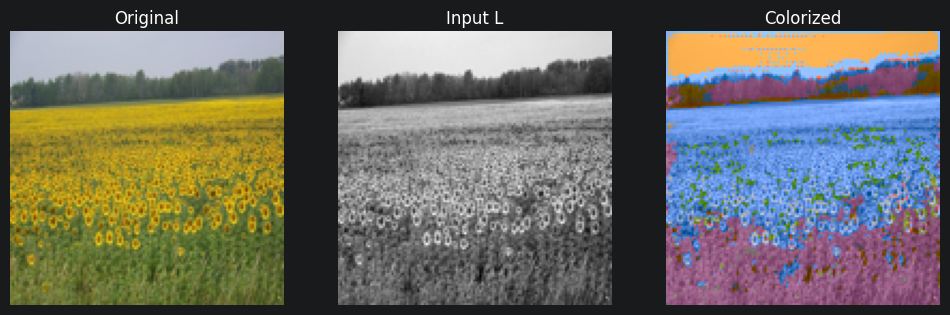

In [102]:
original, colorized, classes = colorize_image(
    "../data/test/Image_48.jpg",
    model,
    kmeans,
    device=device
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(
    color.rgb2gray(original),
    cmap="gray"
)
plt.title("Input L")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(colorized)
plt.title("Colorized")
plt.axis("off")

plt.show()